In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json

# **Data Ingestion**

In [5]:
df = pd.read_csv(r"C:\Users\Win 10\Desktop\kh\kharidyar-chatbot\Datasets\sentiment_dataset.csv")

In [6]:
df

,text,label
0,در آینده با به بازار آمدن این دوربین سعی می‌کن...,0
1,برای پوست چرب می‌باشد چون پوست من خشک راضی نیستم,-1
2,264 ثبت شده است.,0
3,علیرغم اینکه روی محصول نوشته التیامبخش و با تو...,-1
4,من این کرم را حدود عدد ماه پیش گرفتم وهر شب با...,-1
...,...,...
13469,من با تخفیف خریدم. کف و بوش خیلی خوبه,1
13470,خوبه است که به این راحتی میشود ازش استفاده کرد...,-1
13471,من الان عدد روزه استفاده کردم ولی فعلاً نتیجه ...,-1
13472,پنل پشتی iPod از استیل براق است.,0


## **Data Analysis**

Text(0.5, 0.98, 'Label Counts')

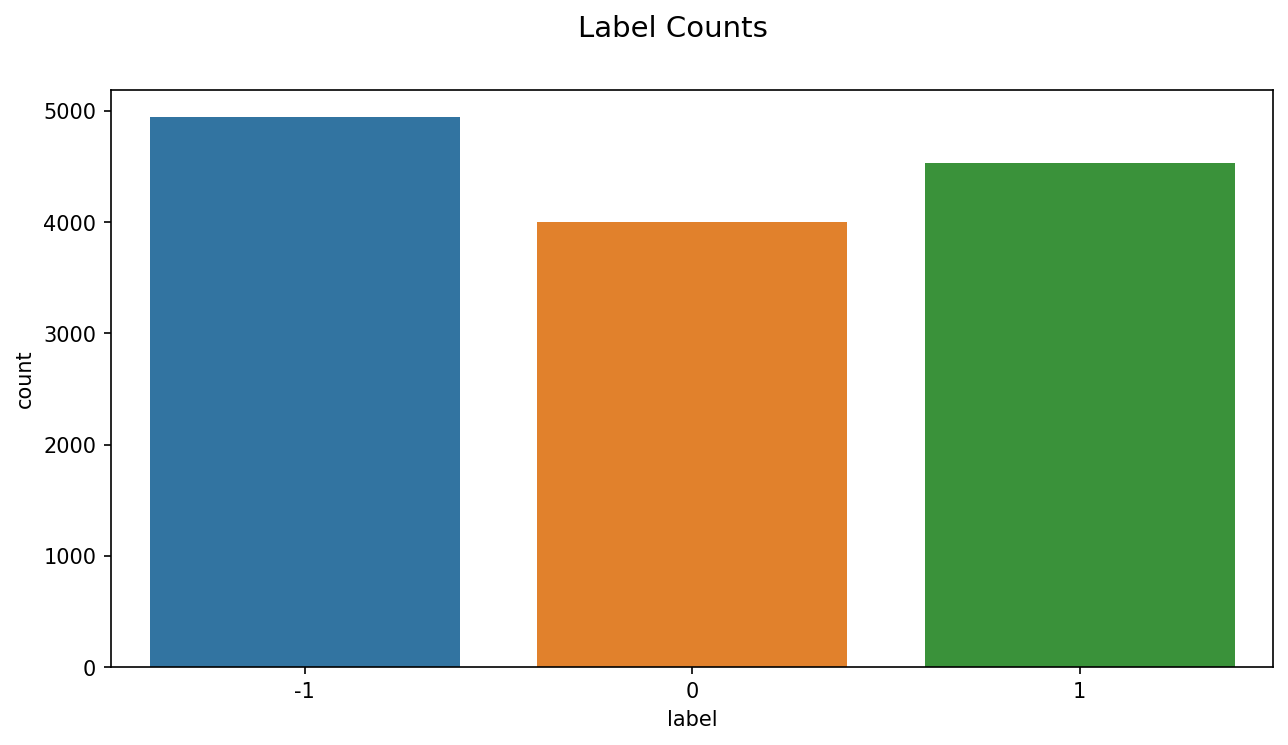

In [12]:
plt.figure(figsize=(10, 5), dpi=150)
sns.countplot(data=df, x="label")
plt.suptitle("Label Counts", size=14)

In [13]:
df["number_of_token"] = df["text"].apply(lambda x: len(x.split(" ")))
df["text_length"] = df["text"].apply(lambda x: len(x))

Text(0.5, 0.98, 'Boxen Plot of Tokens')

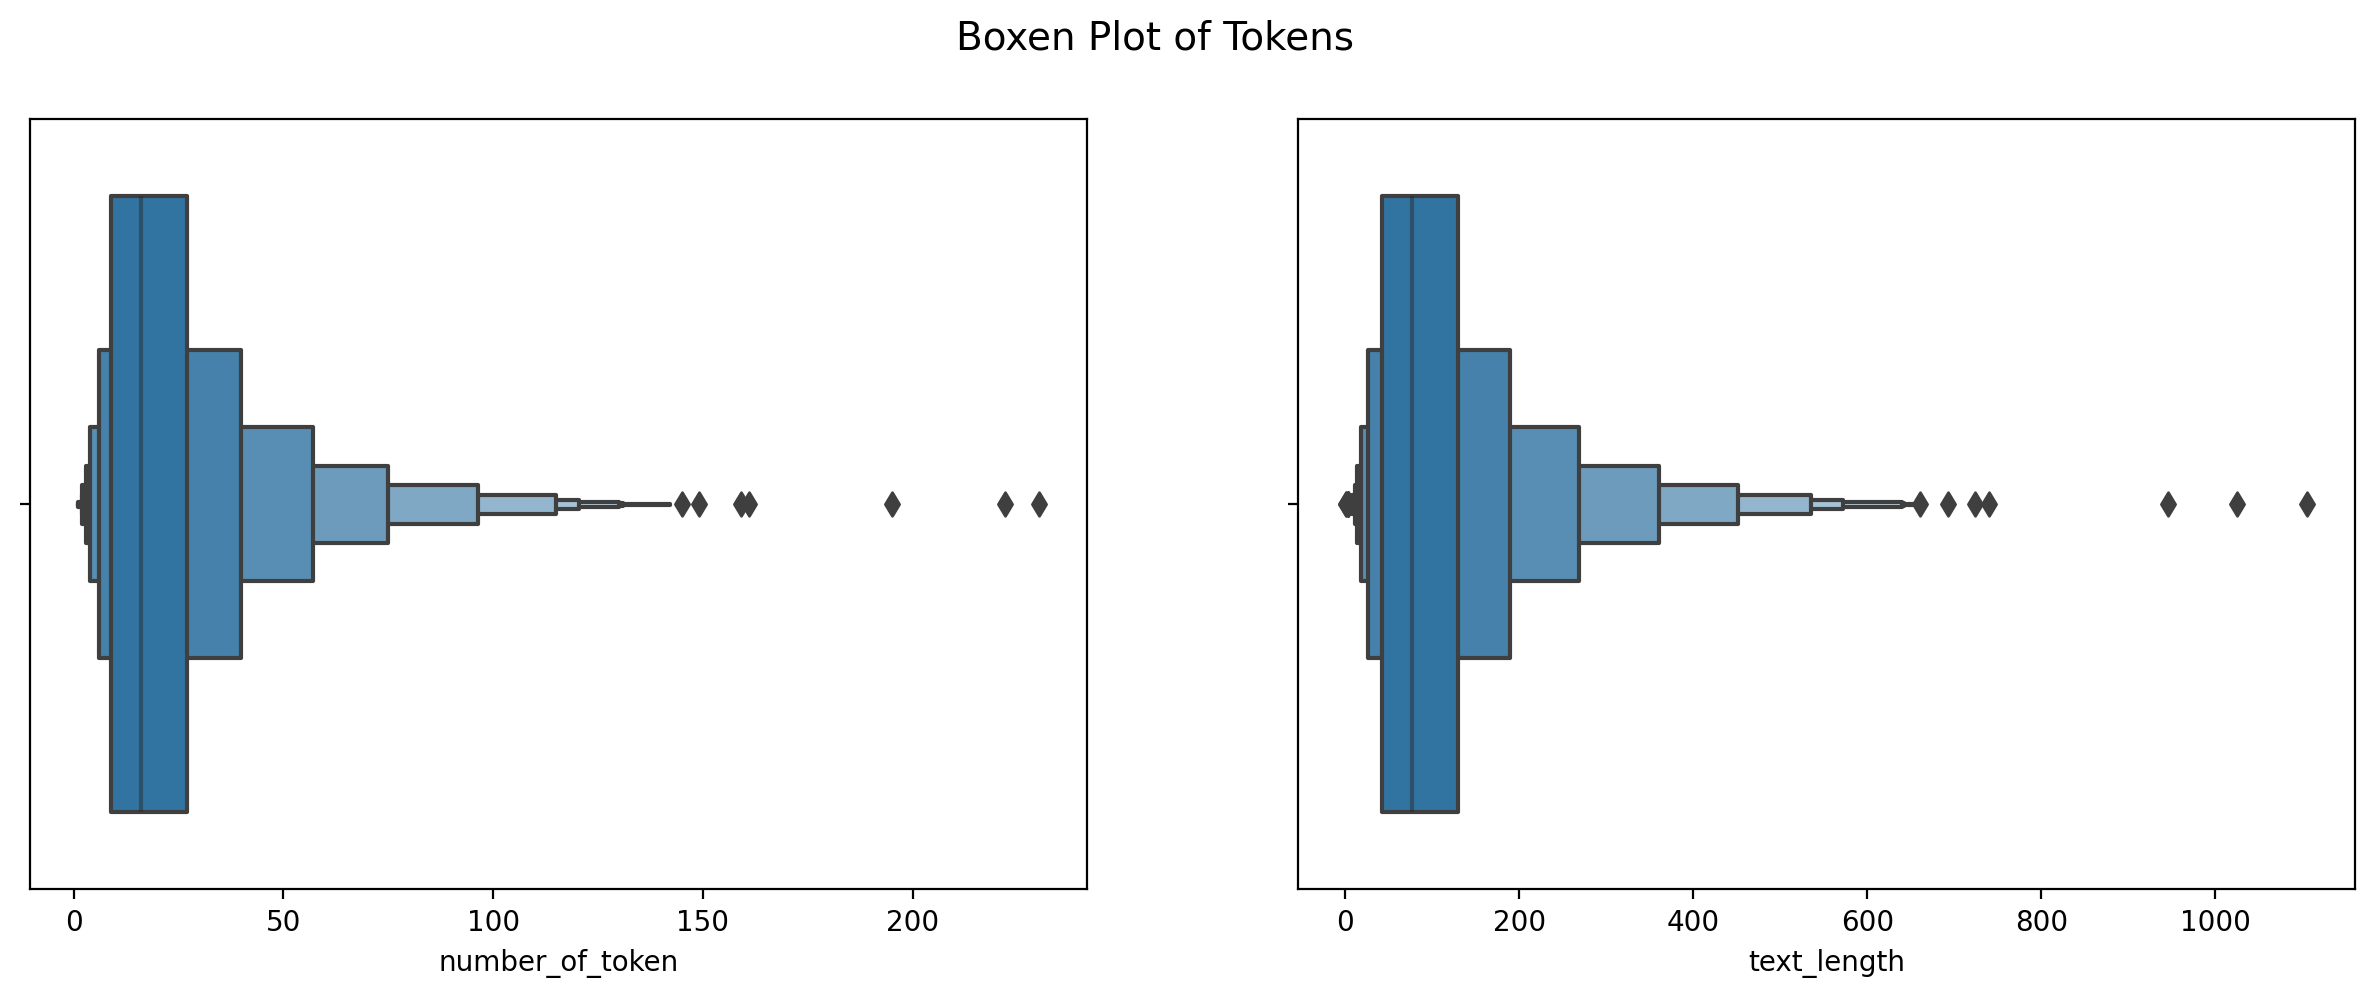

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5), dpi=200)
sns.boxenplot(data=df, x="number_of_token", ax=axes[0])
sns.boxenplot(data=df, x="text_length", ax=axes[1])
plt.suptitle("Boxen Plot of Tokens", size=14)

Text(0.5, 0.98, 'KDE Plot of Tokens')

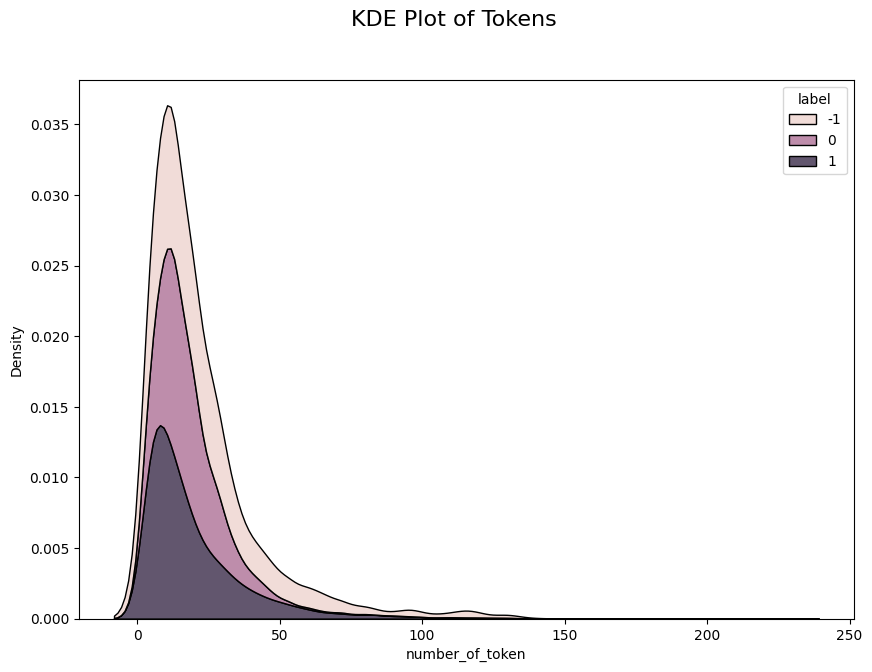

In [24]:
plt.figure(figsize=(10, 7))
sns.kdeplot(data=df, x="number_of_token", hue="label", multiple="stack")
plt.suptitle("KDE Plot of Tokens", size=16)

## **Token Analysis**

In [33]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
cv_1 = CountVectorizer(max_df=0.001)
cv_2 = CountVectorizer(ngram_range=(1, 2))
vect_1 = cv_1.fit_transform(df["text"]).toarray()
vect_2 = cv_2.fit_transform(df["text"]).toarray()

In [34]:
print(f"Vocab size (1-garam): {vect_1.shape[1]}")
print(f"Vocab size (2-garam): {vect_2.shape[1]}")

Vocab size (1-garam): 8047
Vocab size (2-garam): 83900


## **Test The Model**

In [39]:
from pickle import load
with open(r"C:\Users\Win 10\Desktop\kh\kharidyar-chatbot\Models\sentiment_recognizer_model.pkl", "rb") as f:
    sentiment_classifier = load(f)

In [44]:
sentiment_classifier.predict(["تجربه خیلی بد و داغونی بود"])

array([-1], dtype=int64)